✅ Available scalar tags:
['time/fps', 'rollout/ep_len_mean', 'rollout/ep_rew_mean', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/value_loss']


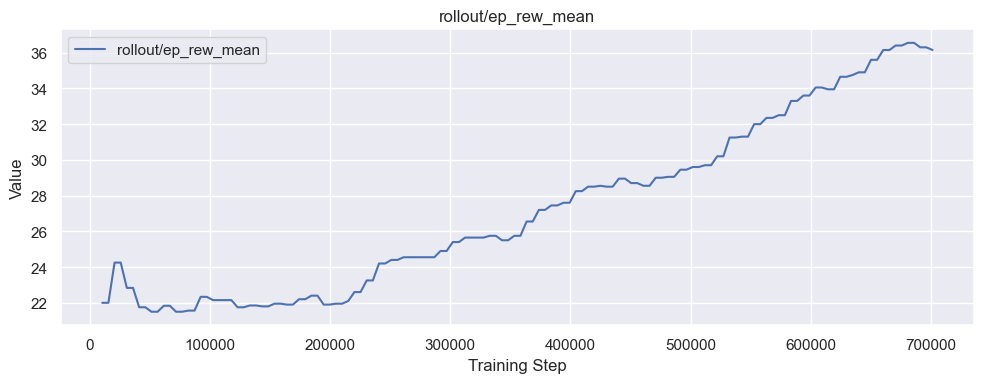

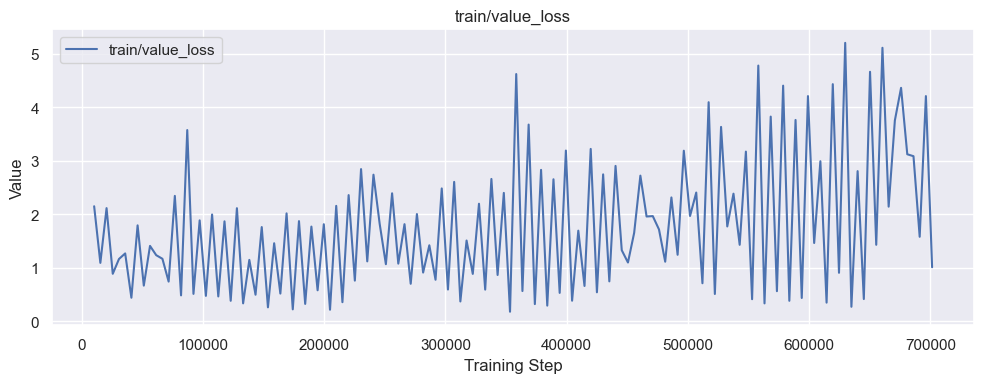

⚠️ Tag not found: train/policy_loss


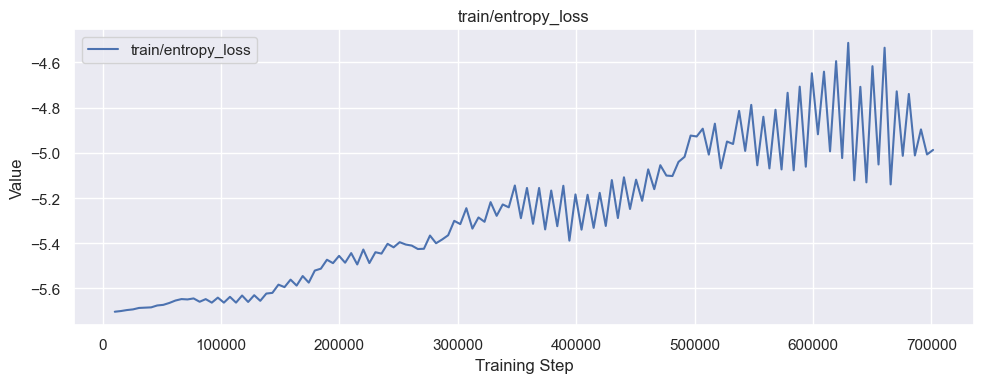

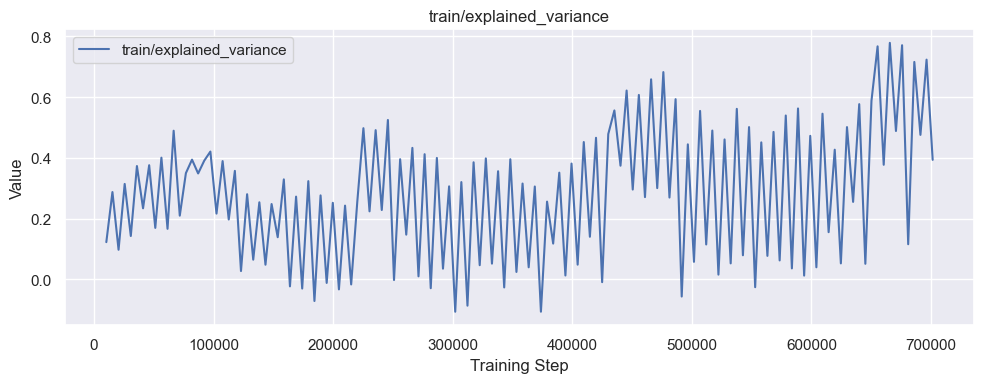

In [25]:
# Install dependencies if needed
# !pip install tensorboard pandas matplotlib seaborn

from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style='darkgrid')

# 🔧 Set this to your PPO TensorBoard log directory
# log_dir = 'src/dr_alns/trained_models/pspAlnsEnv/29_PPO_ActorCriticPolicy_100000_10_04-02_13-44/ppo_logs/'
# log_dir = 'src/dr_alns/trained_models/pspAlnsEnv/30_PPO_ActorCriticPolicy_1000000_10_04-02_14-33/tensorboard_logging_1'
# log_dir = 'src/dr_alns/trained_models/pspAlnsEnv/36_PPO_ActorCriticPolicy_1000000_10_04-03_15-29/tensorboard_logging_1'
# log_dir = 'src/dr_alns/trained_models/pspAlnsEnv/39_PPO_ActorCriticPolicy_700000_10_04-04_16-51/tensorboard_logging_1'
# log_dir = 'src/dr_alns/trained_models/pspAlnsEnv/40_PPO_ActorCriticPolicy_700000_10_04-04_20-17/tensorboard_logging_1'
log_dir = 'src/dr_alns/trained_models/pspAlnsEnv/42_PPO_ActorCriticPolicy_700000_10_04-04_21-02/tensorboard_logging_1' #12.20%
# log_dir = 'src/dr_alns/trained_models/pspAlnsEnv/43_PPO_ActorCriticPolicy_700000_10_04-04_22-19/tensorboard_logging_1' #12.35% 
# log_dir = 'src/dr_alns/trained_models/pspAlnsEnv/44_PPO_ActorCriticPolicy_700000_10_04-04_23-16/tensorboard_logging_1' #13.05%
# log_dir = 'src/dr_alns/trained_models/pspAlnsEnv/45_PPO_ActorCriticPolicy_700000_10_04-05_00-47/tensorboard_logging_1' #12.18%
# log_dir = 'src/dr_alns/trained_models/pspAlnsEnv/46_PPO_ActorCriticPolicy_1000000_10_04-05_02-15/tensorboard_logging_1' #12.44
# log_dir = 'src/dr_alns/trained_models/pspAlnsEnv/49_PPO_ActorCriticPolicy_1000000_10_04-05_11-18/tensorboard_logging_1' #21
# 50 51 is a wrong ru
# log_dir = 'src/dr_alns/trained_models/pspAlnsEnv/52_PPO_ActorCriticPolicy_1000000_10_04-05_12-32/tensorboard_logging_1' #21 change reward

# 🔍 Find the latest TensorBoard event file
event_file = None
for root, _, files in os.walk(log_dir):
    for file in files:
        if 'tfevents' in file:
            event_file = os.path.join(root, file)
            break
    if event_file:
        break

if not event_file:
    raise FileNotFoundError("No TensorBoard event file found in log directory!")

# 📥 Load scalar data from TensorBoard log
ea = EventAccumulator(event_file)
ea.Reload()

# Show available scalar tags
print("✅ Available scalar tags:")
print(ea.Tags()['scalars'])

# 📦 Helper to extract a scalar tag into a DataFrame
def extract_scalar_df(tag):
    events = ea.Scalars(tag)
    return pd.DataFrame({
        'step': [e.step for e in events],
        'value': [e.value for e in events]
    })

# 📈 Plot selected key metrics
tags_to_plot = [
    'rollout/ep_rew_mean',
    'train/value_loss',
    'train/policy_loss',
    'train/entropy_loss',
    'train/explained_variance'
]

for tag in tags_to_plot:
    if tag in ea.Tags()['scalars']:
        df = extract_scalar_df(tag)
        plt.figure(figsize=(10, 4))
        plt.plot(df['step'], df['value'], label=tag)
        plt.title(f'{tag}')
        plt.xlabel('Training Step')
        plt.ylabel('Value')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ Tag not found: {tag}")

In [ ]:
# from 39, 
# reduce learning rate
# increase n_steps
# increase vf_coef
# increase n_epochs
# ent_coef = 0.01 
# larger network (policy_kwargs)

# this is for 39
# # Arguments that get passed to the constructor of your class instance
# # as config={} keyword
# environment:
#     env_id: pspAlnsEnv
#     iterations: 1000

# main:
#     model: PPO
#     policy: ActorCriticPolicy
#     n_workers: 10             # Parallel environments
#     n_steps: 700000          # Steps to train
#     save_every: 200000       # Save a checkpoint of the model every n steps (must be divisible by n_workers!)
#     eval_callback: false      # Intermediate evaluation of the model (true or false)
#     eval_every: 10000         # evaluation parameter: Evaluate the model every n steps
#     eval_episodes: 10         # evaluation parameter: Number of episodes to evaluate the model
#     deterministic: false      # evaluation parameter: Use deterministic actions for evaluation (true or false)

# models:
#     PPO:
#         n_steps: 256          # Batch size (n_steps * n_workers)
#         batch_size: 64        # Number of minibatches for SGD/Adam updates
#         n_epochs: 10          # Number of iterations for SGD/Adam
#         gamma: 0.99           # Discount factor for future rewards
#         gae_lambda: 0.95      # Generalized advantage estimation, for controlling variance/bias tradeoff (lam in PPO2)
#         clip_range: 0.2       # Clip factor for PPO (the action probability distribution of the updated policy cannot differ from the old one by this fraction [measured by KL divergence])
#         ent_coef: 0.0         # Entropy loss coefficient (higher values encourage more exploration)
#         learning_rate: 0.0001 # LR
#         vf_coef: 0.5          # The contribution of value function loss to the total loss of the network
#         max_grad_norm: 0.5    # Max range of the gradient clipping
#         verbose: 1            # the verbosity level: 0 no output, 1 info, 2 debug

# self.improvement,
#                 self.cost_difference_from_best,
#                 is_current_best,
#                 self.stagcount,
#                 self.iteration / self.max_iterations,
#                 self.current_updated,
#                 self.current_improved,
#                 self.temperature,
#                 temp_normalized,
#                 acceptance_ratio,
#                 objective_std,
#                 self.episode_reward / (self.iteration + 1),
#                 success_rate,

In [ ]:
# # 40
# # # Arguments that get passed to the constructor of your class instance
# # as config={} keyword
# environment:
#     env_id: pspAlnsEnv
#     iterations: 1000

# main:
#     model: PPO
#     policy: ActorCriticPolicy
#     n_workers: 10             # Parallel environments
#     n_steps: 700000          # Steps to train
#     save_every: 200000       # Save a checkpoint of the model every n steps (must be divisible by n_workers!)
#     eval_callback: false      # Intermediate evaluation of the model (true or false)
#     eval_every: 10000         # evaluation parameter: Evaluate the model every n steps
#     eval_episodes: 10         # evaluation parameter: Number of episodes to evaluate the model
#     deterministic: false      # evaluation parameter: Use deterministic actions for evaluation (true or false)

# models:
#     PPO:
#         n_steps: 512        # Batch size (n_steps * n_workers)
#         batch_size: 64        # Number of minibatches for SGD/Adam updates
#         n_epochs: 20          # Number of iterations for SGD/Adam
#         gamma: 0.99           # Discount factor for future rewards
#         gae_lambda: 0.95      # Generalized advantage estimation, for controlling variance/bias tradeoff (lam in PPO2)
#         clip_range: 0.2       # Clip factor for PPO (the action probability distribution of the updated policy cannot differ from the old one by this fraction [measured by KL divergence])
#         ent_coef: 0.01         # Entropy loss coefficient (higher values encourage more exploration)
#         learning_rate: 0.00001 # LR
#         vf_coef: 0.7          # The contribution of value function loss to the total loss of the network
#         max_grad_norm: 0.5    # Max range of the gradient clipping
#         verbose: 1            # the verbosity level: 0 no output, 1 info, 2 debug

#                 self.improvement,
#                 self.cost_difference_from_best,
#                 is_current_best,
#                 self.stagcount,
#                 self.iteration / self.max_iterations,
#                 self.current_updated,
#                 self.current_improved,
#                 self.temperature,
#                 temp_normalized,
#                 acceptance_ratio,
#                 objective_std,
#                 self.episode_reward / (self.iteration + 1),
#                 success_rate,

In [ ]:
#16 /42_PPO_ActorCriticPolicy_700000_10_04-04_21-02
#  self.improvement,
#                 self.cost_difference_from_best,
#                 is_current_best,
#                 self.stagcount,
#                 self.iteration / self.max_iterations,
#                 self.current_updated,
#                 self.current_improved,
#                 self.temperature,
#                 temp_normalized,
#                 acceptance_ratio,
#                 objective_std,
#                 self.episode_reward / (self.iteration + 1),
#                 success_rate,
#                 self.improvement_streak,
#                 avg_reward,
#                 usage_entropy,

# main:
#     model: PPO
#     policy: ActorCriticPolicy
#     n_workers: 10             # Parallel environments
#     n_steps: 700000          # Steps to train
#     save_every: 200000       # Save a checkpoint of the model every n steps (must be divisible by n_workers!)
#     eval_callback: false      # Intermediate evaluation of the model (true or false)
#     eval_every: 10000         # evaluation parameter: Evaluate the model every n steps
#     eval_episodes: 10         # evaluation parameter: Number of episodes to evaluate the model
#     deterministic: false      # evaluation parameter: Use deterministic actions for evaluation (true or false)

# models:
#     PPO:
#         n_steps: 512        # Batch size (n_steps * n_workers)
#         batch_size: 64        # Number of minibatches for SGD/Adam updates
#         n_epochs: 20          # Number of iterations for SGD/Adam
#         gamma: 0.99           # Discount factor for future rewards
#         gae_lambda: 0.95      # Generalized advantage estimation, for controlling variance/bias tradeoff (lam in PPO2)
#         clip_range: 0.2       # Clip factor for PPO (the action probability distribution of the updated policy cannot differ from the old one by this fraction [measured by KL divergence])
#         ent_coef: 0.01         # Entropy loss coefficient (higher values encourage more exploration)
#         learning_rate: 0.00001 # LR
#         vf_coef: 0.7          # The contribution of value function loss to the total loss of the network
#         max_grad_norm: 0.5    # Max range of the gradient clipping
#         verbose: 1            # the verbosity level: 0 no output, 1 info, 2 debug

#                 self.improvement,
#                 self.cost_difference_from_best,
#                 is_current_best,
#                 self.stagcount,
#                 self.iteration / self.max_iterations,
#                 self.current_updated,
#                 self.current_improved,
#                 self.temperature,
#                 temp_normalized,
#                 acceptance_ratio,
#                 objective_std,
#                 self.episode_reward / (self.iteration + 1),
#                 success_rate,

In [ ]:
# # 16 43 - too aggressive
# #

# # Arguments that get passed to the constructor of your class instance
# # as config={} keyword
# environment:
#     env_id: pspAlnsEnv
#     iterations: 1000

# main:
#     model: PPO
#     policy: ActorCriticPolicy
#     n_workers: 10             # Parallel environments
#     n_steps: 700000          # Steps to train
#     save_every: 200000       # Save a checkpoint of the model every n steps (must be divisible by n_workers!)
#     eval_callback: false      # Intermediate evaluation of the model (true or false)
#     eval_every: 10000         # evaluation parameter: Evaluate the model every n steps
#     eval_episodes: 10         # evaluation parameter: Number of episodes to evaluate the model
#     deterministic: false      # evaluation parameter: Use deterministic actions for evaluation (true or false)

# models:
#     PPO:
#         n_steps: 512        # Batch size (n_steps * n_workers)
#         batch_size: 64        # Number of minibatches for SGD/Adam updates
#         n_epochs: 20          # Number of iterations for SGD/Adam
#         gamma: 0.99           # Discount factor for future rewards
#         gae_lambda: 0.95      # Generalized advantage estimation, for controlling variance/bias tradeoff (lam in PPO2)
#         clip_range: 0.2       # Clip factor for PPO (the action probability distribution of the updated policy cannot differ from the old one by this fraction [measured by KL divergence])
#         ent_coef: 0.02         # Entropy loss coefficient (higher values encourage more exploration)
#         learning_rate: 0.000001 # LR
#         vf_coef: 0.8          # The contribution of value function loss to the total loss of the network
#         max_grad_norm: 0.5    # Max range of the gradient clipping
#         verbose: 1            # the verbosity level: 0 no output, 1 info, 2 debug

#                 self.improvement,
#                 self.cost_difference_from_best,
#                 is_current_best,
#                 self.stagcount,
#                 self.iteration / self.max_iterations,
#                 self.current_updated,
#                 self.current_improved,
#                 self.temperature,
#                 temp_normalized,
#                 acceptance_ratio,
#                 objective_std,
#                 self.episode_reward / (self.iteration + 1),
#                 success_rate,

In [ ]:
# # 16 44 - too aggressive, reduce back vf_coef
# #

# # Arguments that get passed to the constructor of your class instance
# # as config={} keyword
# environment:
#     env_id: pspAlnsEnv
#     iterations: 1000

# main:
#     model: PPO
#     policy: ActorCriticPolicy
#     n_workers: 10             # Parallel environments
#     n_steps: 700000          # Steps to train
#     save_every: 200000       # Save a checkpoint of the model every n steps (must be divisible by n_workers!)
#     eval_callback: false      # Intermediate evaluation of the model (true or false)
#     eval_every: 10000         # evaluation parameter: Evaluate the model every n steps
#     eval_episodes: 10         # evaluation parameter: Number of episodes to evaluate the model
#     deterministic: false      # evaluation parameter: Use deterministic actions for evaluation (true or false)

# models:
#     PPO:
#         n_steps: 512        # Batch size (n_steps * n_workers)
#         batch_size: 64        # Number of minibatches for SGD/Adam updates
#         n_epochs: 20          # Number of iterations for SGD/Adam
#         gamma: 0.99           # Discount factor for future rewards
#         gae_lambda: 0.95      # Generalized advantage estimation, for controlling variance/bias tradeoff (lam in PPO2)
#         clip_range: 0.2       # Clip factor for PPO (the action probability distribution of the updated policy cannot differ from the old one by this fraction [measured by KL divergence])
#         ent_coef: 0.02         # Entropy loss coefficient (higher values encourage more exploration)
#         learning_rate: 0.000001 # LR
#         vf_coef: 0.7          # The contribution of value function loss to the total loss of the network
#         max_grad_norm: 0.5    # Max range of the gradient clipping
#         verbose: 1            # the verbosity level: 0 no output, 1 info, 2 debug

#                 self.improvement,
#                 self.cost_difference_from_best,
#                 is_current_best,
#                 self.stagcount,
#                 self.iteration / self.max_iterations,
#                 self.current_updated,
#                 self.current_improved,
#                 self.temperature,
#                 temp_normalized,
#                 acceptance_ratio,
#                 objective_std,
#                 self.episode_reward / (self.iteration + 1),
#                 success_rate,

In [ ]:
# # 16 45 - too aggressive, reduce back vf_coef, reduce back ent_coef, and increase epochs and steps
# #

# # Arguments that get passed to the constructor of your class instance
# # as config={} keyword
# environment:
#     env_id: pspAlnsEnv
#     iterations: 1000

# main:
#     model: PPO
#     policy: ActorCriticPolicy
#     n_workers: 10             # Parallel environments
#     n_steps: 1000000          # Steps to train
#     save_every: 200000       # Save a checkpoint of the model every n steps (must be divisible by n_workers!)
#     eval_callback: false      # Intermediate evaluation of the model (true or false)
#     eval_every: 10000         # evaluation parameter: Evaluate the model every n steps
#     eval_episodes: 10         # evaluation parameter: Number of episodes to evaluate the model
#     deterministic: false      # evaluation parameter: Use deterministic actions for evaluation (true or false)

# models:
#     PPO:
#         n_steps: 512        # Batch size (n_steps * n_workers)
#         batch_size: 64        # Number of minibatches for SGD/Adam updates
#         n_epochs: 30          # Number of iterations for SGD/Adam
#         gamma: 0.99           # Discount factor for future rewards
#         gae_lambda: 0.95      # Generalized advantage estimation, for controlling variance/bias tradeoff (lam in PPO2)
#         clip_range: 0.2       # Clip factor for PPO (the action probability distribution of the updated policy cannot differ from the old one by this fraction [measured by KL divergence])
#         ent_coef: 0.01        # Entropy loss coefficient (higher values encourage more exploration)
#         learning_rate: 0.000001 # LR
#         vf_coef: 0.7          # The contribution of value function loss to the total loss of the network
#         max_grad_norm: 0.5    # Max range of the gradient clipping
#         verbose: 1            # the verbosity level: 0 no output, 1 info, 2 debug

#                 self.improvement,
#                 self.cost_difference_from_best,
#                 is_current_best,
#                 self.stagcount,
#                 self.iteration / self.max_iterations,
#                 self.current_updated,
#                 self.current_improved,
#                 self.temperature,
#                 temp_normalized,
#                 acceptance_ratio,
#                 objective_std,
#                 self.episode_reward / (self.iteration + 1),
#                 success_rate,

In [ ]:
# # 16 46 - too aggressive, reduce back vf_coef, and increase epochs and steps
# #

# # Arguments that get passed to the constructor of your class instance
# # as config={} keyword
# environment:
#     env_id: pspAlnsEnv
#     iterations: 1000

# main:
#     model: PPO
#     policy: ActorCriticPolicy
#     n_workers: 10             # Parallel environments
#     n_steps: 1000000          # Steps to train
#     save_every: 200000       # Save a checkpoint of the model every n steps (must be divisible by n_workers!)
#     eval_callback: false      # Intermediate evaluation of the model (true or false)
#     eval_every: 10000         # evaluation parameter: Evaluate the model every n steps
#     eval_episodes: 10         # evaluation parameter: Number of episodes to evaluate the model
#     deterministic: false      # evaluation parameter: Use deterministic actions for evaluation (true or false)

# models:
#     PPO:
#         n_steps: 512        # Batch size (n_steps * n_workers)
#         batch_size: 64        # Number of minibatches for SGD/Adam updates
#         n_epochs: 30          # Number of iterations for SGD/Adam
#         gamma: 0.99           # Discount factor for future rewards
#         gae_lambda: 0.95      # Generalized advantage estimation, for controlling variance/bias tradeoff (lam in PPO2)
#         clip_range: 0.2       # Clip factor for PPO (the action probability distribution of the updated policy cannot differ from the old one by this fraction [measured by KL divergence])
#         ent_coef: 0.01        # Entropy loss coefficient (higher values encourage more exploration)
#         learning_rate: 0.000001 # LR
#         vf_coef: 0.7          # The contribution of value function loss to the total loss of the network
#         max_grad_norm: 0.5    # Max range of the gradient clipping
#         verbose: 1            # the verbosity level: 0 no output, 1 info, 2 debug

#                 self.improvement,
#                 self.cost_difference_from_best,
#                 is_current_best,
#                 self.stagcount,
#                 self.iteration / self.max_iterations,
#                 self.current_updated,
#                 self.current_improved,
#                 self.temperature,
#                 temp_normalized,
#                 acceptance_ratio,
#                 objective_std,
#                 self.episode_reward / (self.iteration + 1),
#                 success_rate,

In [ ]:
# # 21 49 -

# # Arguments that get passed to the constructor of your class instance
# # as config={} keyword
# environment:
#     env_id: pspAlnsEnv
#     iterations: 1000

# main:
#     model: PPO
#     policy: ActorCriticPolicy
#     n_workers: 10             # Parallel environments
#     n_steps: 1000000          # Steps to train
#     save_every: 200000       # Save a checkpoint of the model every n steps (must be divisible by n_workers!)
#     eval_callback: false      # Intermediate evaluation of the model (true or false)
#     eval_every: 10000         # evaluation parameter: Evaluate the model every n steps
#     eval_episodes: 10         # evaluation parameter: Number of episodes to evaluate the model
#     deterministic: false      # evaluation parameter: Use deterministic actions for evaluation (true or false)

# models:
#     PPO:
#         n_steps: 512        # Batch size (n_steps * n_workers)
#         batch_size: 64        # Number of minibatches for SGD/Adam updates
#         n_epochs: 30          # Number of iterations for SGD/Adam
#         gamma: 0.99           # Discount factor for future rewards
#         gae_lambda: 0.95      # Generalized advantage estimation, for controlling variance/bias tradeoff (lam in PPO2)
#         clip_range: 0.2       # Clip factor for PPO (the action probability distribution of the updated policy cannot differ from the old one by this fraction [measured by KL divergence])
#         ent_coef: 0.02         # Entropy loss coefficient (higher values encourage more exploration)
#         learning_rate: 0.000001 # LR
#         vf_coef: 0.7          # The contribution of value function loss to the total loss of the network
#         max_grad_norm: 0.5    # Max range of the gradient clipping
#         verbose: 1            # the verbosity level: 0 no output, 1 info, 2 debug

#                 self.improvement,
#                 self.cost_difference_from_best,
#                 is_current_best,
#                 self.stagcount,
#                 self.iteration / self.max_iterations,
#                 self.current_updated,
#                 self.current_improved,
#                 self.temperature,
#                 temp_normalized,
#                 acceptance_ratio,
#                 objective_std,
#                 self.episode_reward / (self.iteration + 1),
#                 success_rate,

In [ ]:
# # 21 50 change reward -

# # Arguments that get passed to the constructor of your class instance
# # as config={} keyword
# environment:
#     env_id: pspAlnsEnv
#     iterations: 1000

# main:
#     model: PPO
#     policy: ActorCriticPolicy
#     n_workers: 10             # Parallel environments
#     n_steps: 1000000          # Steps to train
#     save_every: 200000       # Save a checkpoint of the model every n steps (must be divisible by n_workers!)
#     eval_callback: false      # Intermediate evaluation of the model (true or false)
#     eval_every: 10000         # evaluation parameter: Evaluate the model every n steps
#     eval_episodes: 10         # evaluation parameter: Number of episodes to evaluate the model
#     deterministic: false      # evaluation parameter: Use deterministic actions for evaluation (true or false)

# models:
#     PPO:
#         n_steps: 512        # Batch size (n_steps * n_workers)
#         batch_size: 64        # Number of minibatches for SGD/Adam updates
#         n_epochs: 30          # Number of iterations for SGD/Adam
#         gamma: 0.99           # Discount factor for future rewards
#         gae_lambda: 0.95      # Generalized advantage estimation, for controlling variance/bias tradeoff (lam in PPO2)
#         clip_range: 0.2       # Clip factor for PPO (the action probability distribution of the updated policy cannot differ from the old one by this fraction [measured by KL divergence])
#         ent_coef: 0.02         # Entropy loss coefficient (higher values encourage more exploration)
#         learning_rate: 0.000001 # LR
#         vf_coef: 0.7          # The contribution of value function loss to the total loss of the network
#         max_grad_norm: 0.5    # Max range of the gradient clipping
#         verbose: 1            # the verbosity level: 0 no output, 1 info, 2 debug

#                 self.improvement,
#                 self.cost_difference_from_best,
#                 is_current_best,
#                 self.stagcount,
#                 self.iteration / self.max_iterations,
#                 self.current_updated,
#                 self.current_improved,
#                 self.temperature,
#                 temp_normalized,
#                 acceptance_ratio,
#                 objective_std,
#                 self.episode_reward / (self.iteration + 1),
#                 success_rate,